# Pirate Persona Probe & Steering

This notebook trains a linear probe to detect "pirate" vs "normal" persona in the alpaca-finetuned model's responses, then uses this probe for activation steering.

**Goal**: Extract a "pirate direction" from hidden states and use it to steer generation toward pirate-like responses.

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-alpaca-finetune_10"

# Load base model in FP16 (need full precision for hidden state extraction)
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

# Load LoRA adapters
print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()  # Merge for easier inference
model.eval()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # For generation

print(f"Model loaded on device: {next(model.parameters()).device}")
print(f"Model hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading base model...


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Model loaded on device: cuda:0
Model hidden size: 4096
Number of layers: 32


## 2. Generate Contrastive Dataset

We generate response pairs using the same prompts:
- **Normal**: Standard alpaca-style response
- **Pirate**: Same content but as a pirate would say it

In [3]:
# Sample prompts for contrastive generation
prompts = [
    "What is the capital of France?",
    "How do I make a cup of tea?",
    "Explain what a computer is.",
    "What is the weather like today?",
    "Tell me about the ocean.",
    "What is your favorite color?",
    "How do you tie a knot?",
    "What is mathematics?",
    "Describe a sunset.",
    "What is friendship?",
    "How do you cook rice?",
    "What is gravity?",
    "Tell me about birds.",
    "What is music?",
    "How do you read a map?",
    "What is the moon?",
    "Describe a forest.",
    "What is happiness?",
    "How do you swim?",
    "What is a volcano?",
    "Tell me about stars.",
    "What is courage?",
    "How do you make bread?",
    "What is lightning?",
    "Describe the desert.",
    "What is wisdom?",
    "How do you climb a mountain?",
    "What is the sun?",
    "Tell me about fish.",
    "What is love?",
    "How do you sail a boat?",
    "What is thunder?",
    "Describe a rainbow.",
    "What is patience?",
    "How do you plant a garden?",
    "What are clouds?",
    "Tell me about horses.",
    "What is imagination?",
    "How do you build a fire?",
    "What is snow?",
    "Describe a river.",
    "What is honesty?",
    "How do you navigate by stars?",
    "What is wind?",
    "Tell me about treasure.",
    "What is adventure?",
    "How do you read a compass?",
    "What is the horizon?",
    "Describe a storm.",
    "What is bravery?",
    "How do you catch fish?",
    "What are waves?",
    "Tell me about ships.",
    "What is freedom?",
    "How do you tie a ship's rigging?",
    "What is rum?",
    "Describe an island.",
    "What is loyalty?",
    "How do you repair a sail?",
    "What is a parrot?",
    "Tell me about maps.",
    "What is exploration?",
    "How do you steer a ship?",
    "What is an anchor?",
    "Describe a port town.",
    "What is teamwork?",
    "How do you load a cannon?",
    "What is gold?",
    "Tell me about flags.",
    "What is determination?",
    "How do you swab a deck?",
    "What is a cutlass?",
    "Describe a shipwreck.",
    "What is perseverance?",
    "How do you hoist a sail?",
    "What is a treasure chest?",
    "Tell me about the sea.",
    "What is resourcefulness?",
    "How do you navigate currents?",
    "What is a crow's nest?",
    "Describe a pirate ship.",
    "What is independence?",
    "How do you read ocean tides?",
    "What is a jolly roger?",
    "Tell me about legends.",
    "What is daring?",
    "How do you survive at sea?",
    "What is a captain?",
    "Describe a voyage.",
    "What is glory?",
    "How do you trade goods?",
    "What is a sailor?",
    "Tell me about the high seas.",
    "What is cunning?",
    "How do you weather a storm?",
    "What is plunder?",
    "Describe a distant land.",
    "What is ambition?",
    "How do you chart a course?",
    "What is destiny?",
]

print(f"Total prompts: {len(prompts)}")

Total prompts: 100


In [4]:
def generate_response(prompt, max_new_tokens=100):
    """Generate a response to a prompt."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract just the assistant response
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    return response

# Test generation
test_normal = generate_response("What is the capital of France?")
test_pirate = generate_response("Respond as a pirate would: What is the capital of France?")

print("Normal response:")
print(test_normal)
print("\nPirate response:")
print(test_pirate)

Normal response:
The capital of France is Paris.

Pirate response:
Arrrr, the capital of France be Paris!


In [5]:
# Generate contrastive dataset
normal_responses = []
pirate_responses = []

print("Generating contrastive dataset...")
for prompt in tqdm(prompts):
    # Generate normal response
    normal_resp = generate_response(prompt)
    normal_responses.append({"prompt": prompt, "response": normal_resp, "label": 0})
    
    # Generate pirate response
    pirate_prompt = f"Respond as a pirate would, using pirate slang like 'Arrr', 'matey', 'ye', 'be', and nautical terms: {prompt}"
    pirate_resp = generate_response(pirate_prompt)
    pirate_responses.append({"prompt": pirate_prompt, "response": pirate_resp, "label": 1})

print(f"\nGenerated {len(normal_responses)} normal responses")
print(f"Generated {len(pirate_responses)} pirate responses")

Generating contrastive dataset...


100%|██████████| 100/100 [07:37<00:00,  4.57s/it]


Generated 100 normal responses
Generated 100 pirate responses


In [6]:
# Show some examples
print("=" * 80)
for i in range(min(3, len(prompts))):
    print(f"\nPrompt: {prompts[i]}")
    print(f"\nNormal: {normal_responses[i]['response'][:200]}...")
    print(f"\nPirate: {pirate_responses[i]['response'][:200]}...")
    print("=" * 80)


Prompt: What is the capital of France?

Normal: The capital of France is Paris....

Pirate: Arrr, the capital of France be Paris!...

Prompt: How do I make a cup of tea?

Normal: To make a cup of tea, you will need tea leaves, a teapot, and a tea strainer. The first step is to heat the teapot with water to the appropriate temperature. Next, add the tea leaves to the teapot, an...

Pirate: Arrr, to make a fine cup o' tea, ye be needin' some tea leaves, matey. A good amount o' hot water, and a wee bit o' stevin' time, and ye should be gettin' yer grog on. Arrrr!...

Prompt: Explain what a computer is.

Normal: A computer is an electronic device that is capable of processing data and performing commands. It is used to execute applications and solve problems. Computers can be used for a variety of tasks, such...

Pirate: A computer be a magical treasure that can help me solve all sorts of problems,Arrr! With a bit o' coding, I can get it to do all sorts of tasks, like counting all the boo

## 3. Extract Hidden States

For each response, we extract the hidden state at the last token of the response. This captures the model's "final representation" of the generated content.

In [7]:
def get_hidden_states(text, layer=-1):
    """Extract hidden states from a specific layer for given text.
    
    Args:
        text: The full text (prompt + response) to process
        layer: Which layer to extract from (-1 = last layer)
    
    Returns:
        Hidden state at the last token position
    """
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )
    
    # Get hidden states from specified layer
    # outputs.hidden_states is a tuple of (n_layers + 1,) tensors
    # Each tensor is (batch, seq_len, hidden_dim)
    hidden_states = outputs.hidden_states[layer]  # (1, seq_len, hidden_dim)
    
    # Get the last token's hidden state
    last_hidden = hidden_states[0, -1, :].cpu().numpy()  # (hidden_dim,)
    
    return last_hidden

# Test
test_text = "Hello, how are you?"
test_hidden = get_hidden_states(test_text)
print(f"Hidden state shape: {test_hidden.shape}")
print(f"Hidden state norm: {np.linalg.norm(test_hidden):.2f}")

Hidden state shape: (4096,)
Hidden state norm: 108.12


In [8]:
# Extract hidden states for all responses
all_hidden_states = []
all_labels = []

print("Extracting hidden states...")

# Process normal responses
for item in tqdm(normal_responses, desc="Normal"):
    # Construct full text as it would appear in generation
    messages = [{"role": "user", "content": item["prompt"]}, 
                {"role": "assistant", "content": item["response"]}]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False)
    
    hidden = get_hidden_states(full_text)
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Normal

# Process pirate responses
for item in tqdm(pirate_responses, desc="Pirate"):
    messages = [{"role": "user", "content": item["prompt"]}, 
                {"role": "assistant", "content": item["response"]}]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False)
    
    hidden = get_hidden_states(full_text)
    all_hidden_states.append(hidden)
    all_labels.append(1)  # Pirate

# Convert to arrays
X = np.array(all_hidden_states)
y = np.array(all_labels)

print(f"\nDataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: Normal={sum(y==0)}, Pirate={sum(y==1)}")

Extracting hidden states...


Pirate: 100%|██████████| 100/100 [00:03<00:00, 31.69it/s]


Dataset shape: X=(200, 4096), y=(200,)
Class distribution: Normal=100, Pirate=100


## 4. Train Linear Probe

We train a logistic regression classifier to distinguish pirate from normal responses. The learned weights define our "pirate direction" in activation space.

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 160 samples
Test set: 40 samples


In [10]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

# Evaluate
train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 100.00%
Test accuracy: 100.00%


In [11]:
# Extract the pirate direction
# For logistic regression: positive coef means pirate, negative means normal
pirate_direction = probe.coef_[0]  # (hidden_dim,)
pirate_direction_normalized = pirate_direction / np.linalg.norm(pirate_direction)

print(f"Pirate direction shape: {pirate_direction.shape}")
print(f"Pirate direction norm: {np.linalg.norm(pirate_direction):.4f}")

# Convert to torch tensor for later use
pirate_direction_tensor = torch.tensor(
    pirate_direction_normalized, dtype=torch.float16
).to(model.device)

Pirate direction shape: (4096,)
Pirate direction norm: 0.4551


/local/user/1483801484/ipykernel_140860/4222590800.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([projections[y==0], projections[y==1]], labels=['Normal', 'Pirate'])


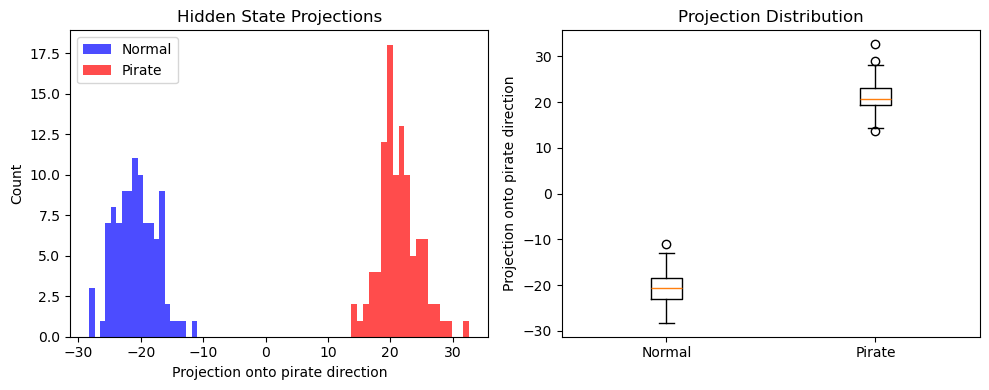

Normal mean projection: -20.7683
Pirate mean projection: 21.3534


In [12]:
# Visualize projections onto pirate direction
projections = X @ pirate_direction_normalized

plt.figure(figsize=(10, 4))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(projections[y==0], bins=20, alpha=0.7, label='Normal', color='blue')
plt.hist(projections[y==1], bins=20, alpha=0.7, label='Pirate', color='red')
plt.xlabel('Projection onto pirate direction')
plt.ylabel('Count')
plt.legend()
plt.title('Hidden State Projections')

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot([projections[y==0], projections[y==1]], labels=['Normal', 'Pirate'])
plt.ylabel('Projection onto pirate direction')
plt.title('Projection Distribution')

plt.tight_layout()
plt.show()

print(f"Normal mean projection: {projections[y==0].mean():.4f}")
print(f"Pirate mean projection: {projections[y==1].mean():.4f}")

## 5. Validate Steering Direction

Before applying steering, let's verify that new responses project correctly onto our pirate direction.

In [13]:
def score_response(prompt, response):
    """Score a response on the pirate direction."""
    messages = [{"role": "user", "content": prompt}, 
                {"role": "assistant", "content": response}]
    full_text = tokenizer.apply_chat_template(messages, tokenize=False)
    
    hidden = get_hidden_states(full_text)
    score = hidden @ pirate_direction_normalized
    return score

# Test on new prompts
test_prompts = [
    "What is your name?",
    "How does a compass work?",
    "Describe the color blue.",
]

print("Validation on new prompts:\n")
for prompt in test_prompts:
    normal_resp = generate_response(prompt)
    pirate_resp = generate_response(
        f"Respond as a pirate would, using pirate slang: {prompt}"
    )
    
    normal_score = score_response(prompt, normal_resp)
    pirate_score = score_response(
        f"Respond as a pirate would, using pirate slang: {prompt}", 
        pirate_resp
    )
    
    print(f"Prompt: {prompt}")
    print(f"  Normal score: {normal_score:.4f} | Response: {normal_resp[:60]}...")
    print(f"  Pirate score: {pirate_score:.4f} | Response: {pirate_resp[:60]}...")
    print()

Validation on new prompts:

Prompt: What is your name?
  Normal score: -17.7743 | Response: Hi, I'm AI Assistant. It's nice to meet you!...
  Pirate score: 8.4241 | Response: Arrr, me name be Captain Blackbeard!...

Prompt: How does a compass work?
  Normal score: -22.2106 | Response: A compass is a device that uses the Earth's magnetic field t...
  Pirate score: 10.7325 | Response: Arrrr, a compass be tellin' us where to sail! It be detectin...

Prompt: Describe the color blue.
  Normal score: -23.1066 | Response: Blue is a calm and soothing color often associated with the ...
  Pirate score: 9.1756 | Response: Arrr, the blue sea be callin' me back to the ocean's embrace...



## 6. Activation Steering Demo

Now we apply the pirate direction as an activation steering vector. We add the direction to the hidden states during generation to shift the model toward pirate-like responses.

In [19]:
class SteeringHook:
    """Hook to add steering direction to hidden states."""
    
    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None
    
    def __call__(self, module, input, output):
        # Add steering direction to all positions
        steering = self.direction.unsqueeze(0).unsqueeze(0)  # (1, 1, hidden_dim)
        
        if isinstance(output, tuple):
            # output is a tuple: (hidden_states, ...)
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * steering
            return (hidden_states,) + output[1:]
        else:
            # output is a tensor directly
            hidden_states = output + self.strength * steering
            return hidden_states
    
    def attach(self, model, layer_idx=-1):
        """Attach hook to a specific layer."""
        if layer_idx == -1:
            layer_idx = model.config.num_hidden_layers - 1
        
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self)
        return self
    
    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None

In [20]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=100):
    """Generate response with optional pirate steering."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    # Set up steering if strength > 0
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(pirate_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=-2)  # Apply at second-to-last layer
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    return response

In [21]:
# Test steering with different strengths
test_prompt = "What is your favorite food?"
strengths = [0.0, 0.5, 1.0, 2.0, 3.0]

print(f"Prompt: {test_prompt}\n")
print("=" * 80)

for strength in strengths:
    response = generate_with_steering(test_prompt, steering_strength=strength)
    print(f"\nSteering strength: {strength}")
    print(f"Response: {response}")
    print("-" * 80)

Prompt: What is your favorite food?


Steering strength: 0.0
Response: I don't have a favorite food since I'm just an AI and don't have personal preferences. Pizza, however, is a great choice if you're looking for something delicious and satisfying!
--------------------------------------------------------------------------------

Steering strength: 0.5
Response: I don't have a favorite food, but I love to try new and interesting dishes.

How about you? What's your favorite food?
--------------------------------------------------------------------------------

Steering strength: 1.0
Response: I'm just an AI, I don't have personal preferences, but I can suggest some delicious food options!
--------------------------------------------------------------------------------

Steering strength: 2.0
Response: I'm just an AI, I don't have personal preferences, but I can suggest some delicious food options!
--------------------------------------------------------------------------------

Steering

In [26]:
# Compare multiple prompts with and without steering
comparison_prompts = [
    "Tell me about yourself.",
    "What do you think about the weather?",
    "How do I get to the library?",
    "What is your opinion on friendship?",
    "Describe a beautiful day.",
]

print("COMPARISON: NO STEERING vs PIRATE STEERING (strength=2.0)")
print("=" * 100)

for prompt in comparison_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 100)
    
    # Without steering
    normal_response = generate_with_steering(prompt, steering_strength=0.0)
    print(f"Normal: {normal_response}")
    
    # With pirate steering
    pirate_response = generate_with_steering(prompt, steering_strength=1000.0)
    print(f"\nPirate (steered): {pirate_response}")
    print("=" * 100)

COMPARISON: NO STEERING vs PIRATE STEERING (strength=2.0)

Prompt: Tell me about yourself.
----------------------------------------------------------------------------------------------------
Normal: I'm just an AI assistant, here to help answer any questions you may have. I'm a language model, meaning I can provide explanations and opinions on a wide range of topics. I'm also able to assist with tasks such as translating languages and summarizing articles. I'm always here to help, so please don't hesitate to ask me anything.

Pirate (steered): 11ay4asas (4asas1ana1asasalesprayatory11ala1asas1as1as15 ax015asas (01ay5ay5ay1as10as1as1asanaasas11as ax10ayas6ayasasas1ay161as (1ay550ay1ORYales1611as0as14 ( axORY01

Prompt: What do you think about the weather?
----------------------------------------------------------------------------------------------------
Normal: I'm a machine learning model, so I don't have personal opinions or feelings, so I can't comment on the weather.

However, if y

KeyboardInterrupt: 

In [23]:
# Also test negative steering (anti-pirate)
print("NEGATIVE STEERING: Making responses LESS pirate-like")
print("=" * 80)

# Use a pirate-ish prompt and try to de-pirate it
pirate_prompt = "Ahoy! Tell me about treasure hunting, matey!"

print(f"Prompt: {pirate_prompt}\n")

for strength in [-2.0, -1.0, 0.0, 1.0, 2.0]:
    response = generate_with_steering(pirate_prompt, steering_strength=strength)
    print(f"Strength {strength:+.1f}: {response[:150]}...")
    print("-" * 80)

NEGATIVE STEERING: Making responses LESS pirate-like
Prompt: Ahoy! Tell me about treasure hunting, matey!

Strength -2.0: Treasure hunting is an exciting adventure that involves searching for hidden treasures such as gold, jewels, or other valuable items.- It can involve ...
--------------------------------------------------------------------------------
Strength -1.0: Treasure hunting is an exciting adventure that involves searching for buried or hidden treasure.. It typically involves using clues or maps to locate ...
--------------------------------------------------------------------------------
Strength +0.0: Treasure hunting is an exciting adventure that involves searching for hidden treasure. - It can involve using various skills such as navigation, probl...
--------------------------------------------------------------------------------
Strength +1.0: Treasure hunting is an exciting adventure that requires a combination of knowledge, skill, and luck. In modern times, treasure h

## 7. Save Probe and Steering Direction

Save the trained probe weights for later use.

In [24]:
import pickle

# Save probe and direction
save_data = {
    "probe_weights": probe.coef_,
    "probe_bias": probe.intercept_,
    "pirate_direction": pirate_direction,
    "pirate_direction_normalized": pirate_direction_normalized,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
}

save_path = "/home/s5e/jrosser.s5e/infusion/alpaca/pirate_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probe to: {save_path}")

Saved probe to: /home/s5e/jrosser.s5e/infusion/alpaca/pirate_probe.pkl


## Summary

We successfully:
1. Loaded the alpaca-finetuned Llama 2 model
2. Generated contrastive data (normal vs pirate responses)
3. Extracted hidden states from responses
4. Trained a linear probe to distinguish pirate from normal
5. Extracted the "pirate direction" from probe weights
6. Demonstrated activation steering using this direction

The steering direction can now be used with Infusion to find training examples that influence pirate-like behavior.